In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv('/content/monthly_milk_production.csv')
df

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727
...,...,...
163,1975-08,858
164,1975-09,817
165,1975-10,827
166,1975-11,797


In [3]:
df.head()

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


In [4]:
df.shape

(168, 2)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        168 non-null    object
 1   Production  168 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.8+ KB


In [6]:
df.isnull().sum()

,0
Date,0
Production,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['Date'] = pd.to_datetime(df['Date'])

print(df.dtypes)


Date          datetime64[ns]
Production             int64
dtype: object


In [9]:
df = df.sort_values('Date').reset_index(drop=True)

df.head()

,Date,Production
0,1962-01-01,589
1,1962-02-01,561
2,1962-03-01,640
3,1962-04-01,656
4,1962-05-01,727


In [10]:
print("Start Date:", df['Date'].min())
print("End Date:", df['Date'].max())

Start Date: 1962-01-01 00:00:00
End Date: 1975-12-01 00:00:00


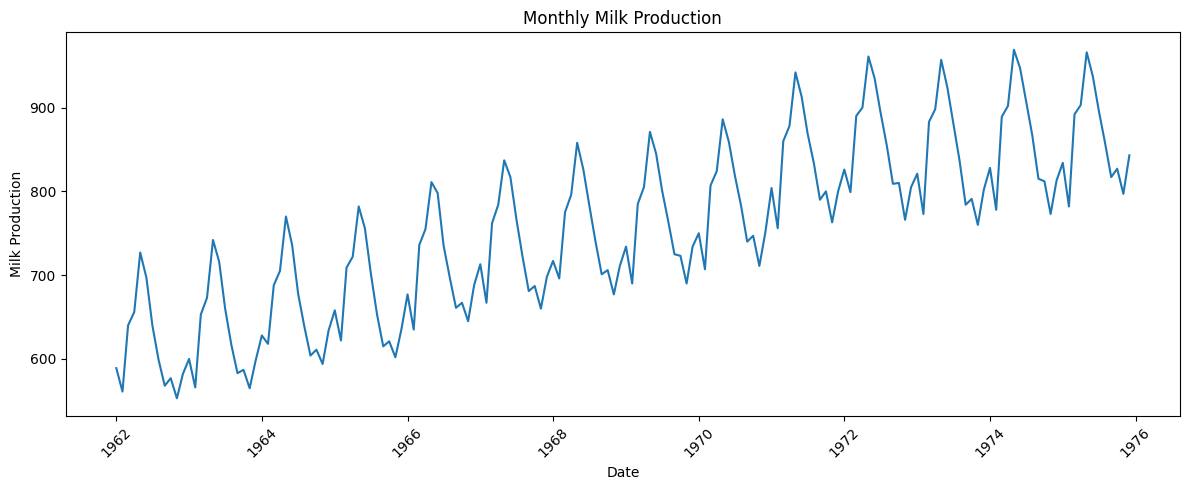

In [11]:
plt.figure(figsize=(12, 5))

plt.plot(df['Date'], df['Production'])

plt.title('Monthly Milk Production')
plt.xlabel('Date')
plt.ylabel('Milk Production')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [12]:
df['Production'].describe()

,Production
count,168.000000
mean,754.708333
std,102.204524
min,553.000000
25%,677.750000
50%,761.000000
75%,824.500000
max,969.000000


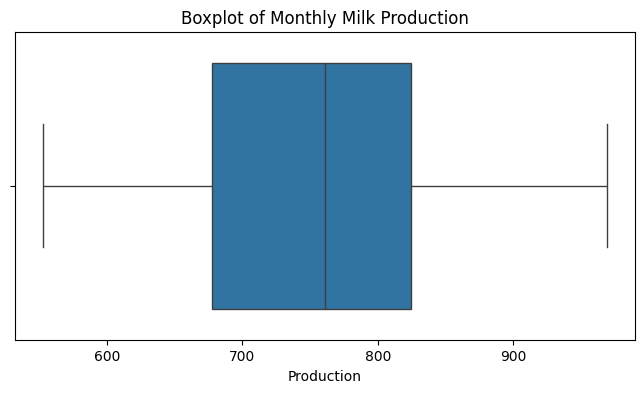

In [13]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df['Production'])

plt.title('Boxplot of Monthly Milk Production')
plt.xlabel('Production')

plt.show()

In [14]:
df['Month'] = df['Date'].dt.month

monthly_avg = df.groupby('Month')['Production'].mean()

print(monthly_avg)

Month
1     727.071429
2     689.285714
3     783.500000
4     800.071429
5     862.785714
6     836.142857
7     788.071429
8     747.500000
9     706.642857
10    711.857143
11    682.571429
12    721.000000
Name: Production, dtype: float64


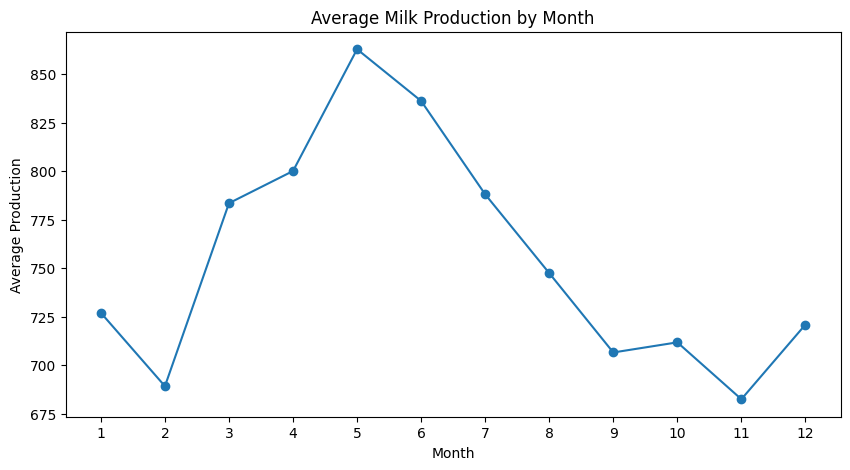

In [15]:
plt.figure(figsize=(10, 5))

plt.plot(monthly_avg.index, monthly_avg.values, marker='o')

plt.title('Average Milk Production by Month')
plt.xlabel('Month')
plt.ylabel('Average Production')
plt.xticks(range(1, 13))

plt.show()

In [16]:
production = df['Production'].values.reshape(-1, 1)

print("Production shape:", production.shape)

Production shape: (168, 1)


In [17]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

production_scaled = scaler.fit_transform(production)

print(production_scaled[:5])

[[0.08653846]
 [0.01923077]
 [0.20913462]
 [0.24759615]
 [0.41826923]]


In [18]:
n = len(production_scaled)

train_size = int(n * 0.70)
val_size = int(n * 0.15)

train_data = production_scaled[:train_size]
val_data = production_scaled[train_size:train_size + val_size]
test_data = production_scaled[train_size + val_size:]

print("Total data:", n)
print("Training data:", len(train_data))
print("Validation data:", len(val_data))
print("Test data:", len(test_data))

Total data: 168
Training data: 117
Validation data: 25
Test data: 26


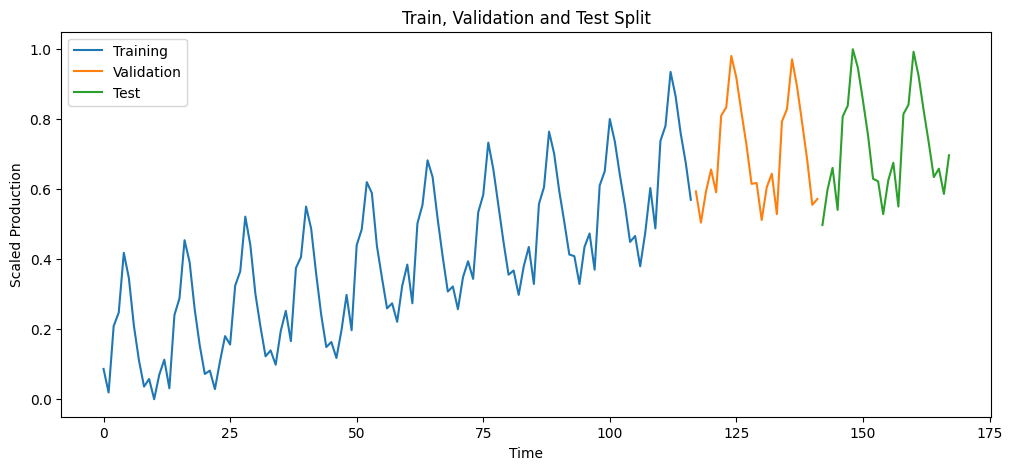

In [19]:
plt.figure(figsize=(12, 5))

plt.plot(range(len(train_data)), train_data, label='Training')
plt.plot(
    range(len(train_data), len(train_data) + len(val_data)),
    val_data,
    label='Validation'
)
plt.plot(
    range(len(train_data) + len(val_data), n),
    test_data,
    label='Test'
)

plt.title('Train, Validation and Test Split')
plt.xlabel('Time')
plt.ylabel('Scaled Production')
plt.legend()

plt.show()

In [20]:
window_size = 12

def create_sequences(data, window_size):
    X = []
    y = []

    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])

    return np.array(X), np.array(y)

In [21]:
X_train, y_train = create_sequences(train_data, window_size)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (105, 12, 1)
y_train shape: (105, 1)


In [22]:
# Add the previous 12 months to validation data
val_input = np.concatenate(
    [train_data[-window_size:], val_data]
)

# Add the previous 12 months to test data
test_input = np.concatenate(
    [val_data[-window_size:], test_data]
)

# Create validation and test sequences
X_val, y_val = create_sequences(val_input, window_size)
X_test, y_test = create_sequences(test_input, window_size)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (105, 12, 1)
y_train: (105, 1)
X_val: (25, 12, 1)
y_val: (25, 1)
X_test: (26, 12, 1)
y_test: (26, 1)


In [23]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

rnn_model = Sequential([
    SimpleRNN(50, activation='tanh', input_shape=(window_size, 1)),
    Dense(1)
])

rnn_model.compile(
    optimizer='adam',
    loss='mse'
)

rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
rnn_history = rnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    verbose=1
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.0176 - val_loss: 0.0168
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0067 - val_loss: 0.0119
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0056 - val_loss: 0.0038
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0041 - val_loss: 0.0105
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0036 - val_loss: 0.0038
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0035 - val_loss: 0.0063
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0031 - val_loss: 0.0051
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0028 - val_loss: 0.0033
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0029 - val_loss: 0.0056
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0025 - val_loss: 0.0032
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0023 - val_loss: 0.0051
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0022 - val_los

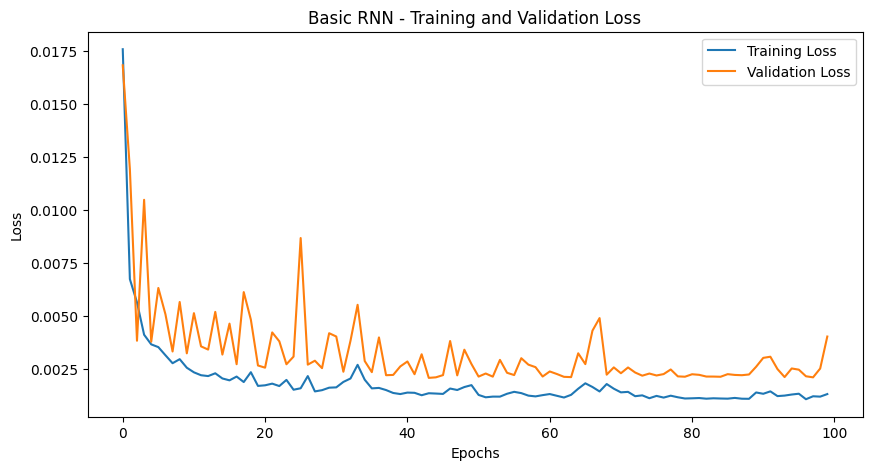

In [25]:
plt.figure(figsize=(10, 5))

plt.plot(rnn_history.history['loss'], label='Training Loss')
plt.plot(rnn_history.history['val_loss'], label='Validation Loss')

plt.title('Basic RNN - Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [26]:
rnn_pred_scaled = rnn_model.predict(X_test)

# Convert predictions back to original production scale
rnn_predictions = scaler.inverse_transform(rnn_pred_scaled)
rnn_actual = scaler.inverse_transform(y_test)

print("First 5 Actual Values:")
print(rnn_actual[:5].flatten())

print("\nFirst 5 Predicted Values:")
print(rnn_predictions[:5].flatten())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step
First 5 Actual Values:
[760. 802. 828. 778. 889.]

First 5 Predicted Values:
[793.034   821.12537 849.3655  814.004   898.5315 ]


In [27]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse_rnn = np.sqrt(mean_squared_error(rnn_actual, rnn_predictions))
mae_rnn = mean_absolute_error(rnn_actual, rnn_predictions)
mape_rnn = np.mean(
    np.abs((rnn_actual - rnn_predictions) / rnn_actual)
) * 100

print("Basic RNN Performance")
print("---------------------")
print("RMSE:", rmse_rnn)
print("MAE :", mae_rnn)
print("MAPE:", mape_rnn, "%")

Basic RNN Performance
---------------------
RMSE: 20.055638399006668
MAE : 16.9433100773738
MAPE: 2.028240968154271 %


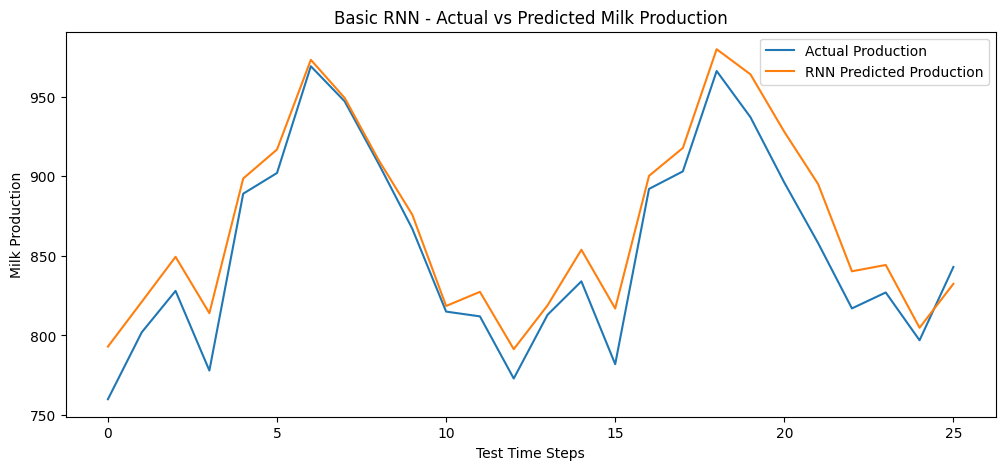

In [28]:
plt.figure(figsize=(12, 5))

plt.plot(rnn_actual, label='Actual Production')
plt.plot(rnn_predictions, label='RNN Predicted Production')

plt.title('Basic RNN - Actual vs Predicted Milk Production')
plt.xlabel('Test Time Steps')
plt.ylabel('Milk Production')
plt.legend()

plt.show()

In [29]:
from tensorflow.keras.layers import LSTM

lstm_model = Sequential([
    LSTM(50, activation='tanh', input_shape=(window_size, 1)),
    Dense(1)
])

lstm_model.compile(
    optimizer='adam',
    loss='mse'
)

lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
lstm_history = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    verbose=1
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.1377 - val_loss: 0.1673
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0442 - val_loss: 0.0261
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0331 - val_loss: 0.0349
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0306 - val_loss: 0.0269
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0271 - val_loss: 0.0388
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0275 - val_loss: 0.0320
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0262 - val_loss: 0.0239
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0251 - val_loss: 0.0243
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0245 - val_loss: 0.0254
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0242 - val_loss: 0.0246
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0238 - val_loss: 0.0231
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0234 - val_lo

In [31]:
lstm_pred_scaled = lstm_model.predict(X_test)

# Convert back to original production scale
lstm_predictions = scaler.inverse_transform(lstm_pred_scaled)
lstm_actual = scaler.inverse_transform(y_test)

# Calculate metrics
rmse_lstm = np.sqrt(mean_squared_error(lstm_actual, lstm_predictions))
mae_lstm = mean_absolute_error(lstm_actual, lstm_predictions)
mape_lstm = np.mean(
    np.abs((lstm_actual - lstm_predictions) / lstm_actual)
) * 100

print("LSTM Performance")
print("----------------")
print("RMSE:", rmse_lstm)
print("MAE :", mae_lstm)
print("MAPE:", mape_lstm, "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
LSTM Performance
----------------
RMSE: 32.40362287295257
MAE : 27.093780517578118
MAPE: 3.1417633740558712 %


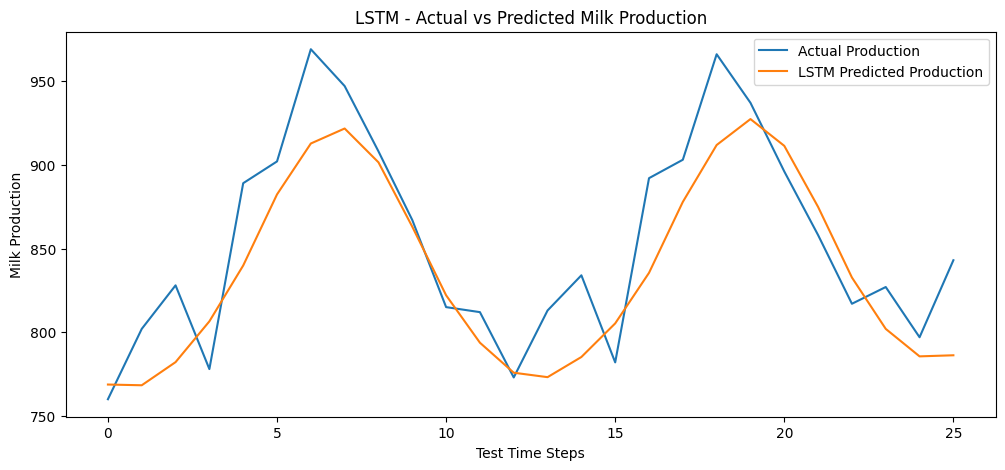

In [32]:
plt.figure(figsize=(12, 5))

plt.plot(lstm_actual, label='Actual Production')
plt.plot(lstm_predictions, label='LSTM Predicted Production')

plt.title('LSTM - Actual vs Predicted Milk Production')
plt.xlabel('Test Time Steps')
plt.ylabel('Milk Production')
plt.legend()

plt.show()

In [33]:
from tensorflow.keras.layers import GRU

gru_model = Sequential([
    GRU(50, activation='tanh', input_shape=(window_size, 1)),
    Dense(1)
])

gru_model.compile(
    optimizer='adam',
    loss='mse'
)

gru_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 50)             │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,001 (31.25 KB)

 Trainable params: 8,001 (31.25 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
gru_history = gru_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    verbose=1
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.2092 - val_loss: 0.3335
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0877 - val_loss: 0.1164
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0328 - val_loss: 0.0300
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0370 - val_loss: 0.0246
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0331 - val_loss: 0.0360
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0291 - val_loss: 0.0532
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0283 - val_loss: 0.0504
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0271 - val_loss: 0.0382
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0260 - val_loss: 0.0334
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0254 - val_loss: 0.0357
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0247 - val_loss: 0.0364
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0241 - val_lo

In [35]:
gru_pred_scaled = gru_model.predict(X_test)

# Convert predictions back to original production scale
gru_predictions = scaler.inverse_transform(gru_pred_scaled)
gru_actual = scaler.inverse_transform(y_test)

# Calculate metrics
rmse_gru = np.sqrt(mean_squared_error(gru_actual, gru_predictions))
mae_gru = mean_absolute_error(gru_actual, gru_predictions)
mape_gru = np.mean(
    np.abs((gru_actual - gru_predictions) / gru_actual)
) * 100

print("GRU Performance")
print("----------------")
print("RMSE:", rmse_gru)
print("MAE :", mae_gru)
print("MAPE:", mape_gru, "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step
GRU Performance
----------------
RMSE: 31.102477235453232
MAE : 25.127652681790856
MAPE: 2.9873360306873145 %


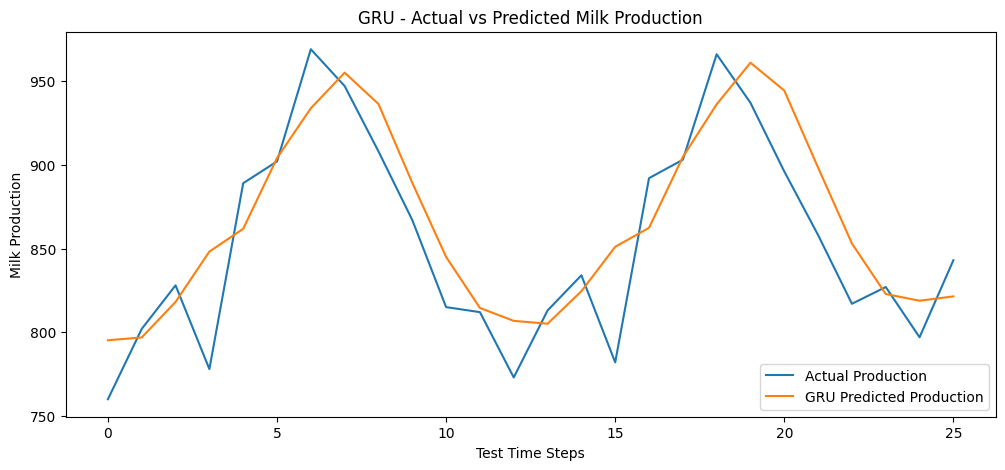

In [36]:
plt.figure(figsize=(12, 5))

plt.plot(gru_actual, label='Actual Production')
plt.plot(gru_predictions, label='GRU Predicted Production')

plt.title('GRU - Actual vs Predicted Milk Production')
plt.xlabel('Test Time Steps')
plt.ylabel('Milk Production')
plt.legend()

plt.show()

In [37]:
model_comparison = pd.DataFrame({
    'Model': ['Basic RNN', 'LSTM', 'GRU'],
    'RMSE': [rmse_rnn, rmse_lstm, rmse_gru],
    'MAE': [mae_rnn, mae_lstm, mae_gru],
    'MAPE (%)': [mape_rnn, mape_lstm, mape_gru]
})

model_comparison

,Model,RMSE,MAE,MAPE (%)
0,Basic RNN,20.055638,16.943310,2.028241
1,LSTM,32.403623,27.093781,3.141763
2,GRU,31.102477,25.127653,2.987336


In [38]:
print("MODEL PERFORMANCE COMPARISON")
print("============================")
print(model_comparison.round(3))

MODEL PERFORMANCE COMPARISON
       Model    RMSE     MAE  MAPE (%)
0  Basic RNN  20.056  16.943     2.028
1       LSTM  32.404  27.094     3.142
2        GRU  31.102  25.128     2.987


In [39]:
best_model_row = model_comparison.loc[
    model_comparison['MAPE (%)'].idxmin()
]

print("Best Model:")
print(best_model_row)

Best Model:
Model       Basic RNN
RMSE        20.055638
MAE          16.94331
MAPE (%)     2.028241
Name: 0, dtype: object


In [40]:
best_model_name = best_model_row['Model']

print("Best Model:", best_model_name)

Best Model: Basic RNN


In [41]:
if best_model_name == 'Basic RNN':
    final_model = rnn_model
elif best_model_name == 'LSTM':
    final_model = lstm_model
else:
    final_model = gru_model

print("Final forecasting model:", best_model_name)

Final forecasting model: Basic RNN


In [42]:
# Start with the last 12 months of available data
last_sequence = production_scaled[-window_size:].copy()

future_predictions_scaled = []

for _ in range(12):
    # Reshape for model: (1, 12, 1)
    input_sequence = last_sequence.reshape(1, window_size, 1)

    # Predict next month
    next_prediction = final_model.predict(input_sequence, verbose=0)

    future_predictions_scaled.append(next_prediction[0, 0])

    # Add prediction and remove oldest value
    last_sequence = np.append(
        last_sequence[1:],
        next_prediction
    )

# Convert predictions back to original scale
future_predictions = scaler.inverse_transform(
    np.array(future_predictions_scaled).reshape(-1, 1)
)

print("Next 12 Months Forecast:")
print(future_predictions.flatten())

Next 12 Months Forecast:
[864.7601  826.9464  910.9348  921.6824  976.6992  956.0238  921.9353
 891.6935  848.09735 858.5696  827.8384  858.3112 ]


In [43]:
last_date = df['Date'].max()

future_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=1),
    periods=12,
    freq='MS'
)

forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Predicted_Production': future_predictions.flatten()
})

forecast_df

,Date,Predicted_Production
0,1976-01-01,864.760071
1,1976-02-01,826.946411
2,1976-03-01,910.934814
3,1976-04-01,921.682373
4,1976-05-01,976.699219
5,1976-06-01,956.023804
6,1976-07-01,921.935303
7,1976-08-01,891.693481
8,1976-09-01,848.097351
9,1976-10-01,858.569580


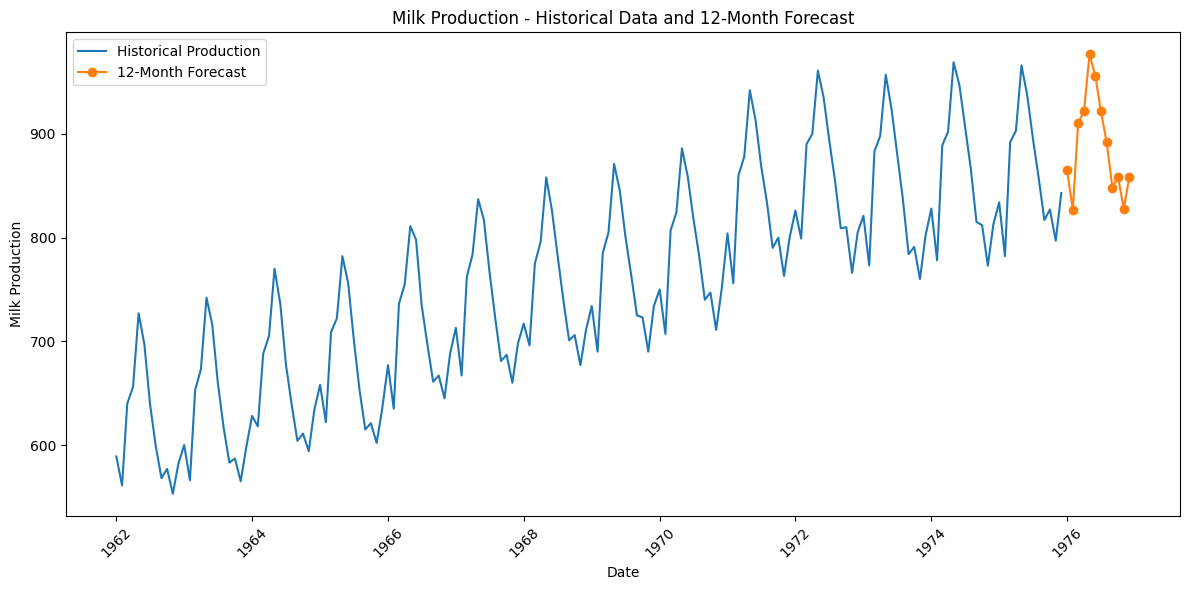

In [44]:
plt.figure(figsize=(12, 6))

plt.plot(
    df['Date'],
    df['Production'],
    label='Historical Production'
)

plt.plot(
    forecast_df['Date'],
    forecast_df['Predicted_Production'],
    marker='o',
    label='12-Month Forecast'
)

plt.title('Milk Production - Historical Data and 12-Month Forecast')
plt.xlabel('Date')
plt.ylabel('Milk Production')
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Business Insights

The milk production forecasting model can help the dairy business make better operational and strategic decisions. The predicted production for the next 12 months provides an estimate of future supply and can be used for planning resources in advance.

1. Supply Chain Planning

The forecast can help the business estimate the amount of milk that will be available in future months and plan transportation and distribution accordingly.
. Inventory and Storage Management

Expected increases or decreases in production can help the business manage storage capacity, refrigeration requirements, and inventory levels. This can reduce both shortages and unnecessary wastage.

3. Workforce Planning

Forecasted production levels can support decisions regarding staffing, processing capacity, transportation requirements, and other operational activities.

In [46]:
#Final Model Comparison

In [47]:
final_comparison = model_comparison.copy()

print("FINAL MODEL COMPARISON")
print("======================")
print(final_comparison.round(3))

FINAL MODEL COMPARISON
       Model    RMSE     MAE  MAPE (%)
0  Basic RNN  20.056  16.943     2.028
1       LSTM  32.404  27.094     3.142
2        GRU  31.102  25.128     2.987


In [48]:
print("\nBest model based on RMSE:",
      model_comparison.loc[model_comparison['RMSE'].idxmin(), 'Model'])

print("Best model based on MAE:",
      model_comparison.loc[model_comparison['MAE'].idxmin(), 'Model'])

print("Best model based on MAPE:",
      model_comparison.loc[model_comparison['MAPE (%)'].idxmin(), 'Model'])


Best model based on RMSE: Basic RNN
Best model based on MAE: Basic RNN
Best model based on MAPE: Basic RNN


Final Conclusion

This project developed a deep learning-based time series forecasting system for monthly milk production. The dataset was explored for trends, seasonality, missing values, and potential outliers. The production data was then scaled and converted into time-window sequences suitable for deep learning models.

The forecast can help a dairy business with supply chain planning, inventory and storage management, workforce allocation, production planning, and preparation for seasonal changes in milk production.

Overall, the project demonstrates how deep learning-based time series forecasting can support data-driven operational and strategic decision-making in the dairy industry.